In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directories to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs,
    load_top_n_runs,
    extract_history,
    add_wall_times,
    plot_2d_histograms,
    plot_training_curves,
    plot_time_to_best,
    plot_speedrun_results,
    print_speedrun_table,
    print_best_hyperparameters,
    save_best_hyperparameters,
    get_optimizer_colors,
    ALL_OPTIMIZERS,
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# Configuration


In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Task settings
TASK_TAG = "shakespeare_minigpt"
ITERATION = 2  # Iteration/batch number to load results from

# Optimizers to analyse
# OPTIMIZERS = ['adam', 'adamw', 'sgd', 'sgd_metric', 'sgd_log_metric', 'muon', 'sgd_rms']
OPTIMIZERS = ALL_OPTIMIZERS  # Uncomment to analyse all optimizers

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Metric configuration
SORT_METRIC = "final_min_val_perplexity"
SORT_ORDER = "+"
METRIC_KEY = "sweep_metric"
DIRECTION = "minimize"

# Speedrun targets (validation perplexity thresholds)
SPEEDRUN_TARGETS = [12.0, 10.0, 8.0, 6.0, 5.0, 4.6, 4.5, 4.4, 4.0, 3.5]
SPEEDRUN_DIRECTION = "below"
SPEEDRUN_METRIC = "val_perplexity"

# History metrics to extract
HISTORY_METRICS = ["train_loss", "val_perplexity", "train_time_seconds"]

# 2D histogram axes
HIST_X = "final_min_perp_epoch"
HIST_Y = "final_min_val_perplexity"

# Time-to-best keys
BEST_EPOCH_KEY = "final_min_perp_epoch"
BEST_METRIC_KEY = "val_perplexity"

colors = get_optimizer_colors(OPTIMIZERS)
print(f"Backend: {BACKEND}")
print(f"Task: {TASK_TAG}, Iteration: {ITERATION}")
print(f"Optimizers: {OPTIMIZERS}")

Backend: local
Task: shakespeare_minigpt, Iteration: 2
Optimizers: ['adam', 'adamw', 'sgd', 'muon', 'sgd_metric', 'sgd_log_metric', 'sgd_rms', 'sgd_learn_scalar', 'sgd_learn_scalar_log', 'sgd_learn_diag', 'sgd_learn_diag_log', 'sgd_offdiag_0_l', 'sgd_offdiag_0_m', 'sgd_offdiag_0_theta', 'sgd_offdiag_l_0', 'sgd_offdiag_l_l', 'sgd_offdiag_l_m', 'sgd_offdiag_l_theta', 'sgd_offdiag_m_0', 'sgd_offdiag_m_l', 'sgd_offdiag_m_m', 'sgd_offdiag_m_theta', 'sgd_offdiag_theta_0', 'sgd_offdiag_theta_l', 'sgd_offdiag_theta_m', 'sgd_offdiag_theta_theta']


# Load Data


In [3]:
best_runs = load_best_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

top_n_runs = load_top_n_runs(
    backend=BACKEND,
    optimizers=OPTIMIZERS,
    n=50,
    task_tag=TASK_TAG,
    project=PROJECT,
    entity=ENTITY,
    results_dir=RESULTS_DIR,
    metric_key=METRIC_KEY,
    direction=DIRECTION,
    sort_metric=SORT_METRIC,
    sort_order=SORT_ORDER,
    iteration=ITERATION,
)

print(f"\nLoaded best runs for {len(best_runs)} optimizers")

Finding best run for adam...
  adam: run_77
Finding best run for adamw...
  adamw: run_158
Finding best run for sgd...


  sgd: run_98
Finding best run for muon...
  muon: run_59
Finding best run for sgd_metric...
  sgd_metric: run_115
Finding best run for sgd_log_metric...


  sgd_log_metric: run_115
Finding best run for sgd_rms...
  sgd_rms: run_175
Finding best run for sgd_learn_scalar...
  sgd_learn_scalar: run_30
Finding best run for sgd_learn_scalar_log...


  sgd_learn_scalar_log: run_30
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_61
Finding best run for sgd_learn_diag_log...
  sgd_learn_diag_log: run_61
Finding best run for sgd_offdiag_0_l...


  sgd_offdiag_0_l: run_46
Finding best run for sgd_offdiag_0_m...
  sgd_offdiag_0_m: run_46
Finding best run for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: run_70
Finding best run for sgd_offdiag_l_0...


...

  adamw: 50 runs
Loading top 50 runs for sgd...
  sgd: 50 runs
Loading top 50 runs for muon...
  muon: 50 runs
Loading top 50 runs for sgd_metric...
  sgd_metric: 50 runs
Loading top 50 runs for sgd_log_metric...
  sgd_log_metric: 50 runs
Loading top 50 runs for sgd_rms...


  sgd_rms: 50 runs
Loading top 50 runs for sgd_learn_scalar...
  sgd_learn_scalar: 50 runs
Loading top 50 runs for sgd_learn_scalar_log...
  sgd_learn_scalar_log: 50 runs
Loading top 50 runs for sgd_learn_diag...
  sgd_learn_diag: 50 runs
Loading top 50 runs for sgd_learn_diag_log...
  sgd_learn_diag_log: 50 runs
Loading top 50 runs for sgd_offdiag_0_l...


  sgd_offdiag_0_l: 50 runs
Loading top 50 runs for sgd_offdiag_0_m...
  sgd_offdiag_0_m: 50 runs
Loading top 50 runs for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: 50 runs
Loading top 50 runs for sgd_offdiag_l_0...
  sgd_offdiag_l_0: 50 runs
Loading top 50 runs for sgd_offdiag_l_l...
  sgd_offdiag_l_l: 50 runs
Loading top 50 runs for sgd_offdiag_l_m...


  sgd_offdiag_l_m: 50 runs
Loading top 50 runs for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: 50 runs
Loading top 50 runs for sgd_offdiag_m_0...
  sgd_offdiag_m_0: 50 runs
Loading top 50 runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 50 runs
Loading top 50 runs for sgd_offdiag_m_m...
  sgd_offdiag_m_m: 50 runs
Loading top 50 runs for sgd_offdiag_m_theta...


  sgd_offdiag_m_theta: 50 runs
Loading top 50 runs for sgd_offdiag_theta_0...
  sgd_offdiag_theta_0: 50 runs
Loading top 50 runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 50 runs
Loading top 50 runs for sgd_offdiag_theta_m...
  sgd_offdiag_theta_m: 50 runs
Loading top 50 runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 50 runs

Loaded best runs for 26 optimizers


# Distribution of Top Runs


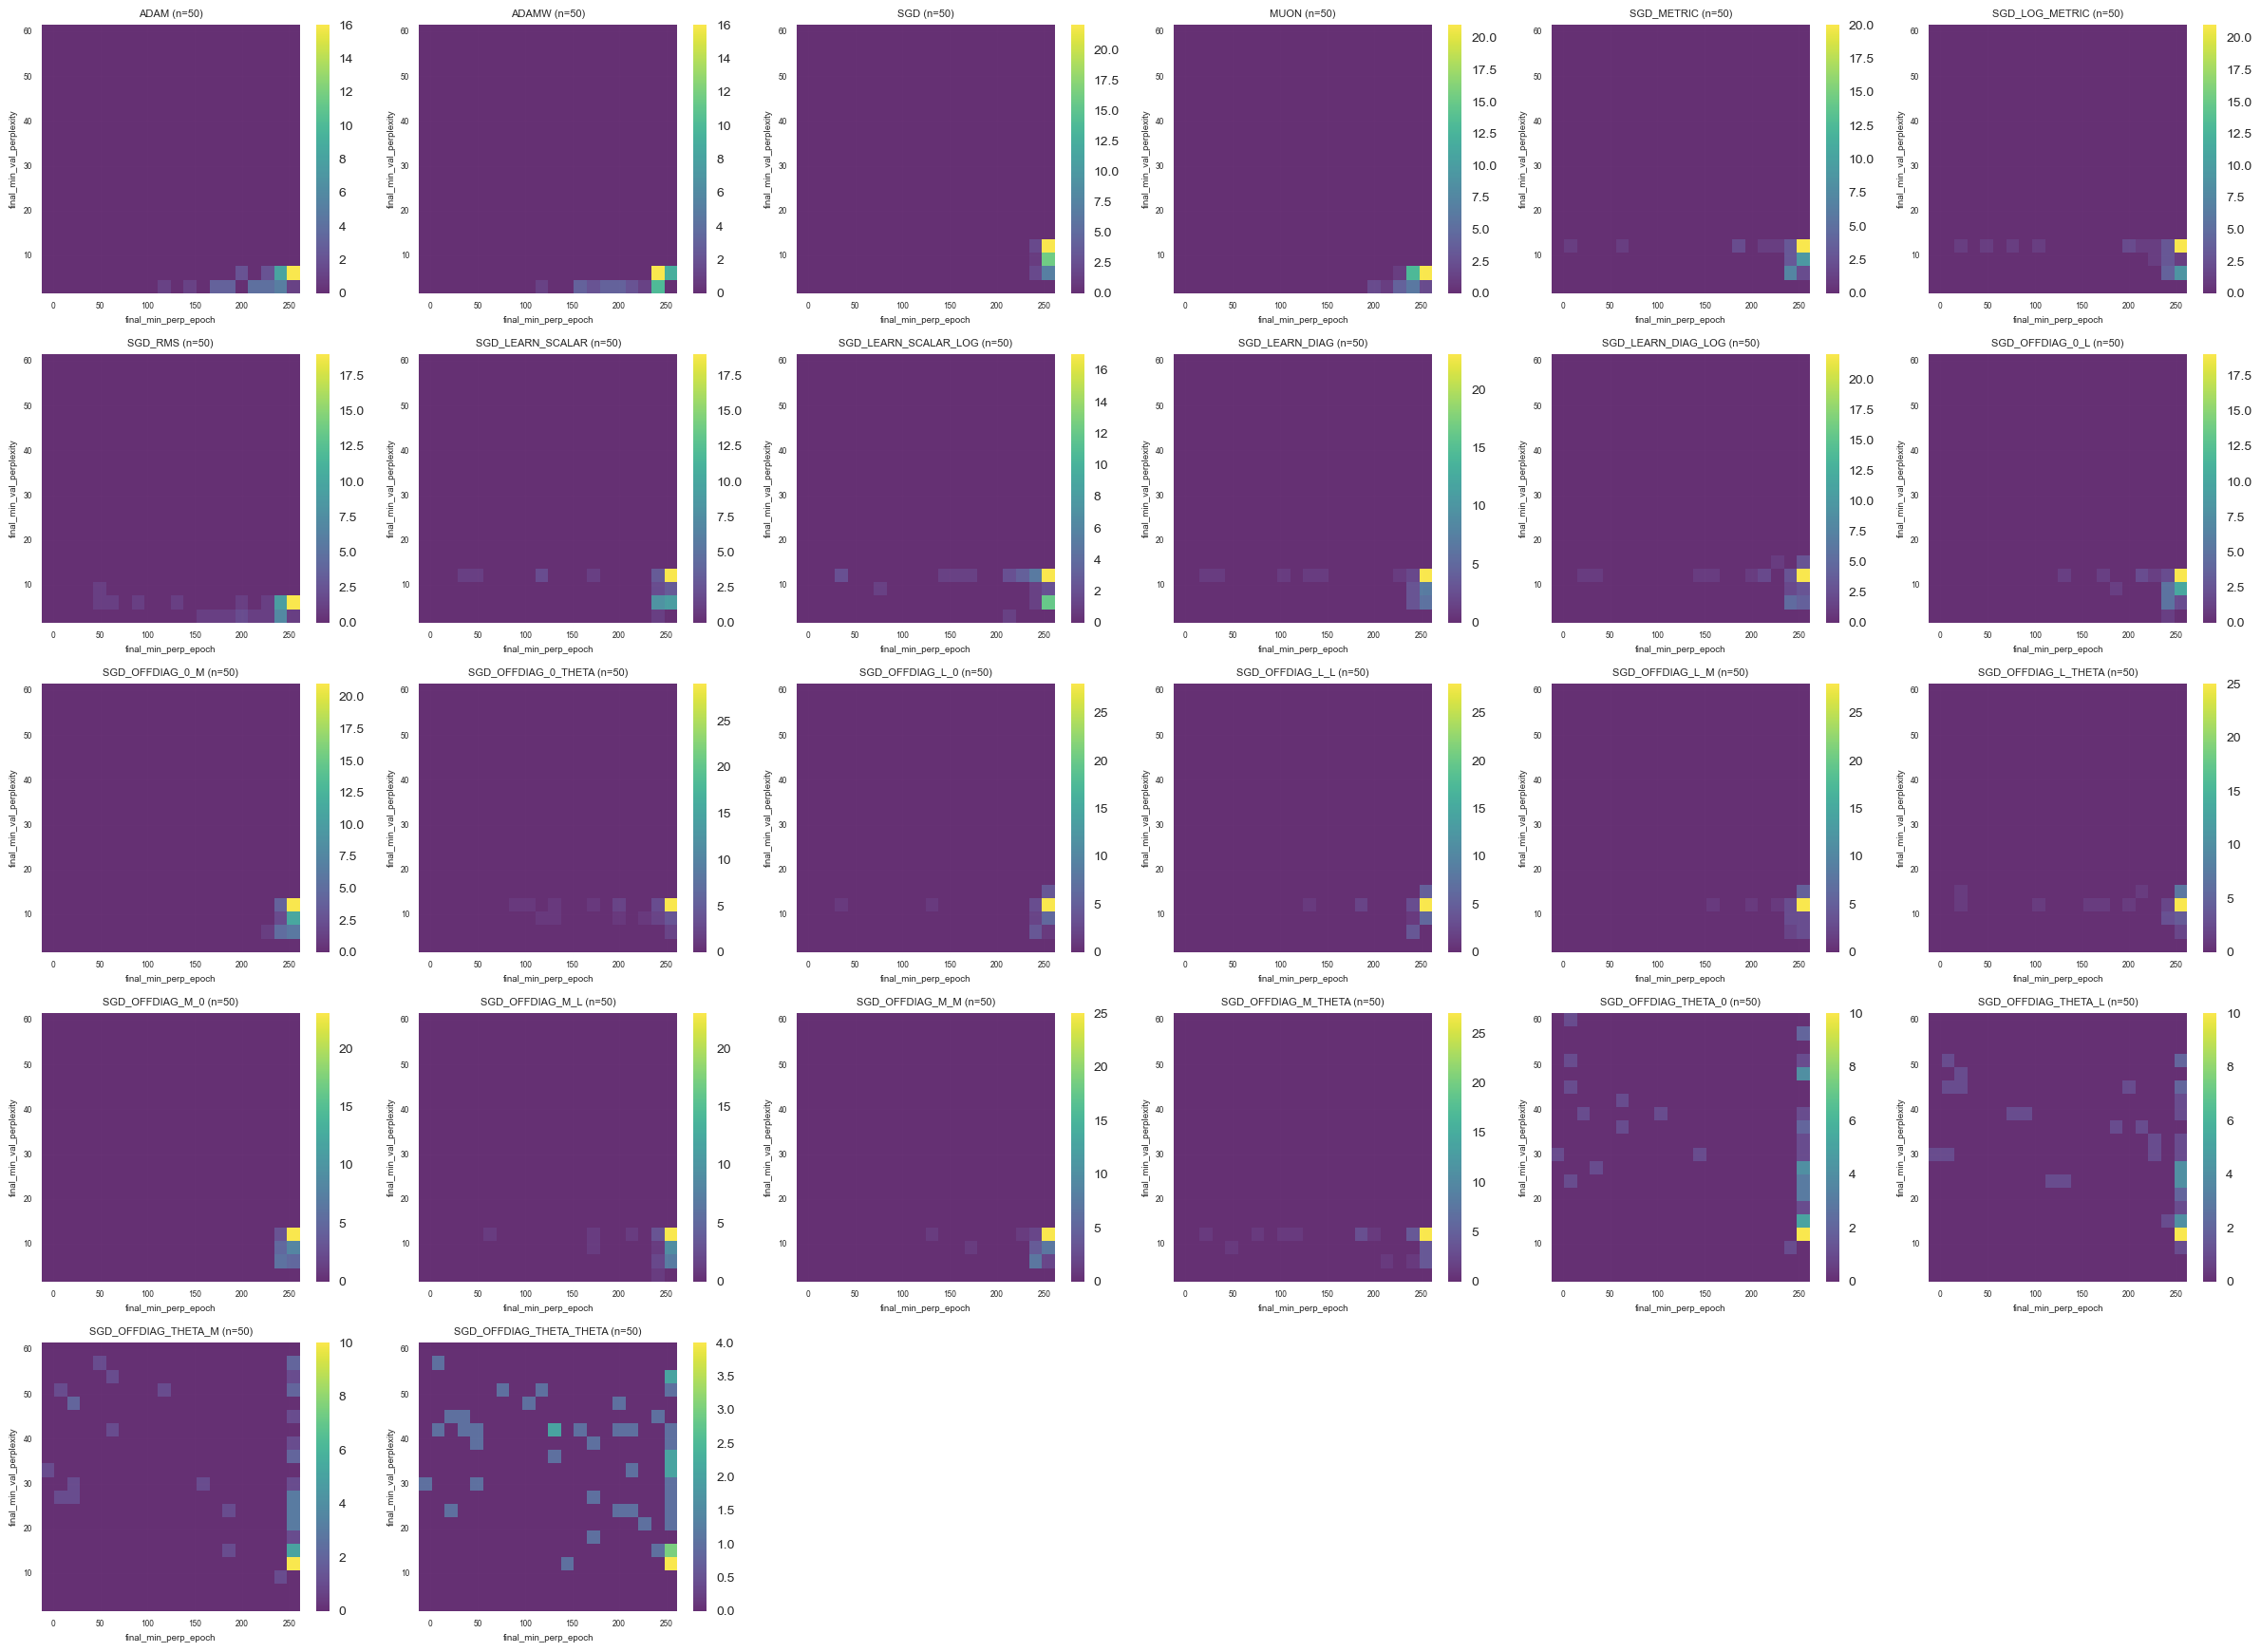

In [4]:
fig = plot_2d_histograms(
    top_n_runs, backend=BACKEND,
    x_metric=HIST_X, y_metric=HIST_Y,
    optimizers=OPTIMIZERS,
)
plt.show()


# Training History


In [5]:
optimizer_data = extract_history(BACKEND, best_runs, HISTORY_METRICS)
add_wall_times(optimizer_data)

print(f"Extracted history for {len(optimizer_data)} optimizers")


Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...
Extracted history for 26 optimizers


Time to reach best metric for each optimizer:
  ADAM                :     7.74s at epoch 225 (val_perplexity: 4.364750)
  ADAMW               :     6.97s at epoch 201 (val_perplexity: 4.384630)
  SGD                 :     6.56s at epoch 249 (val_perplexity: 5.736540)
  MUON                :    13.77s at epoch 248 (val_perplexity: 4.440900)
  SGD_METRIC          :     6.53s at epoch 247 (val_perplexity: 4.880630)
  SGD_LOG_METRIC      :     6.74s at epoch 249 (val_perplexity: 5.096530)
  SGD_RMS             :     8.11s at epoch 245 (val_perplexity: 4.293020)
  SGD_LEARN_SCALAR    :     7.87s at epoch 247 (val_perplexity: 4.420190)
  SGD_LEARN_SCALAR_LOG:     6.21s at epoch 208 (val_perplexity: 4.442780)
  SGD_LEARN_DIAG      :     9.06s at epoch 248 (val_perplexity: 4.636650)
  SGD_LEARN_DIAG_LOG  :     9.47s at epoch 249 (val_perplexity: 4.895630)
  SGD_OFFDIAG_0_L     :     9.71s at epoch 237 (val_perplexity: 4.556790)
  SGD_OFFDIAG_0_M     :    15.56s at epoch 237 (val_perplexity: 4.

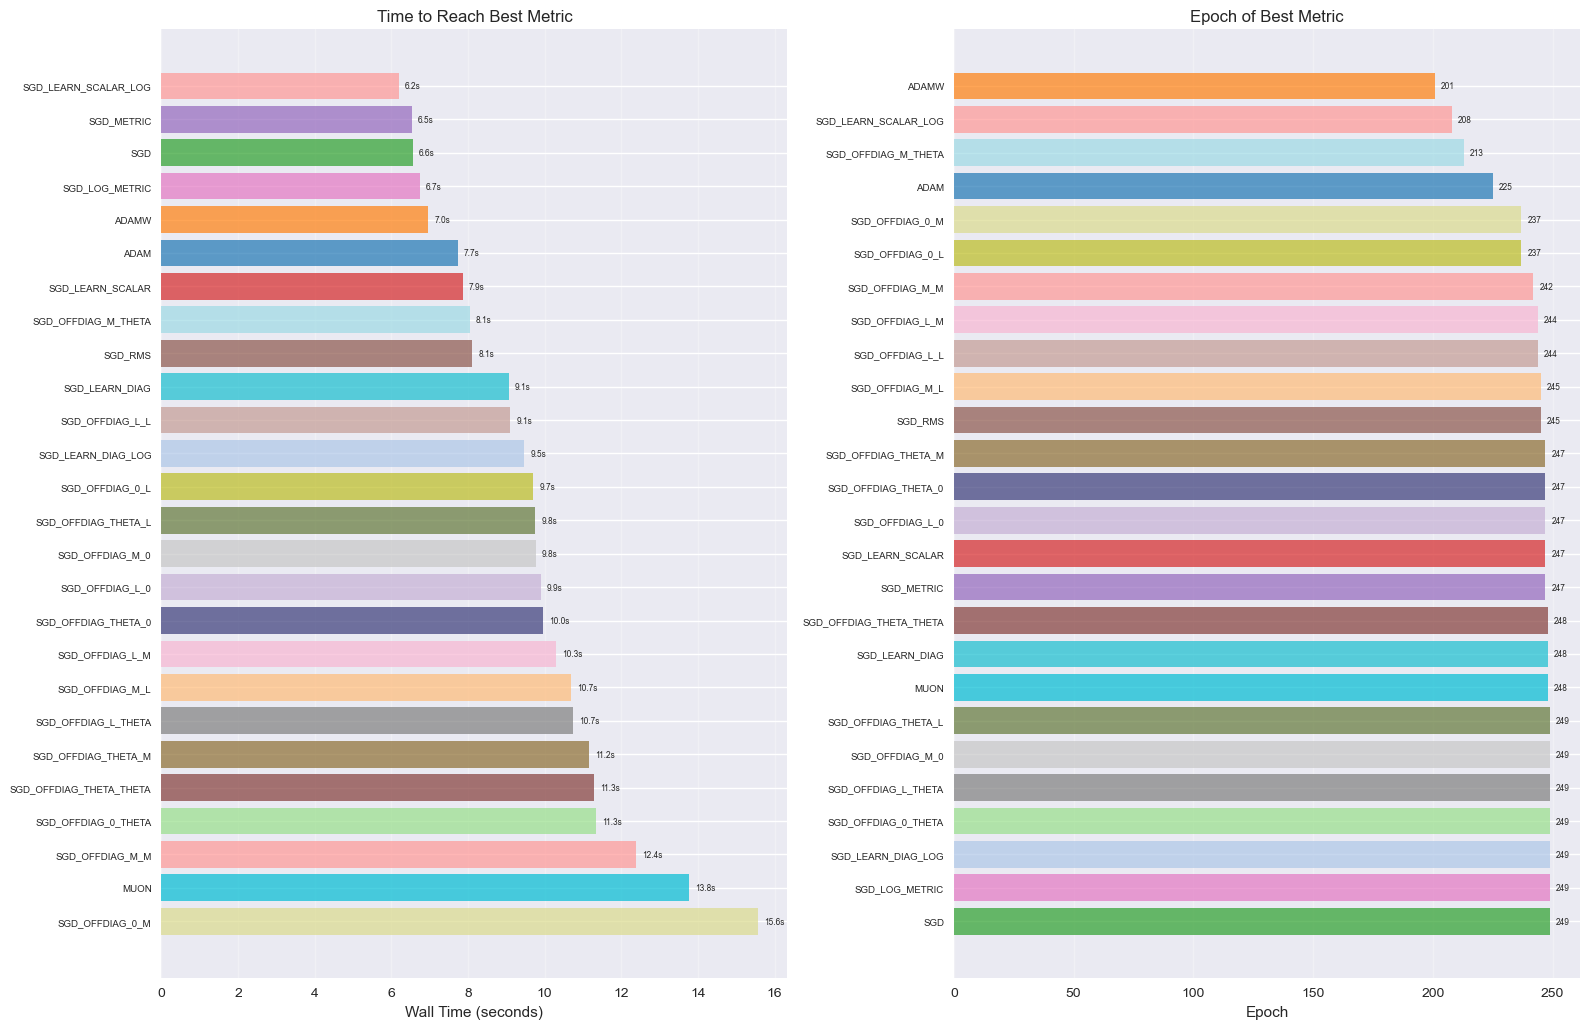

In [6]:
fig = plot_time_to_best(
    best_runs, optimizer_data,
    best_epoch_key=BEST_EPOCH_KEY,
    best_metric_key=BEST_METRIC_KEY,
    colors=colors,
)
plt.show()


# Training Curves


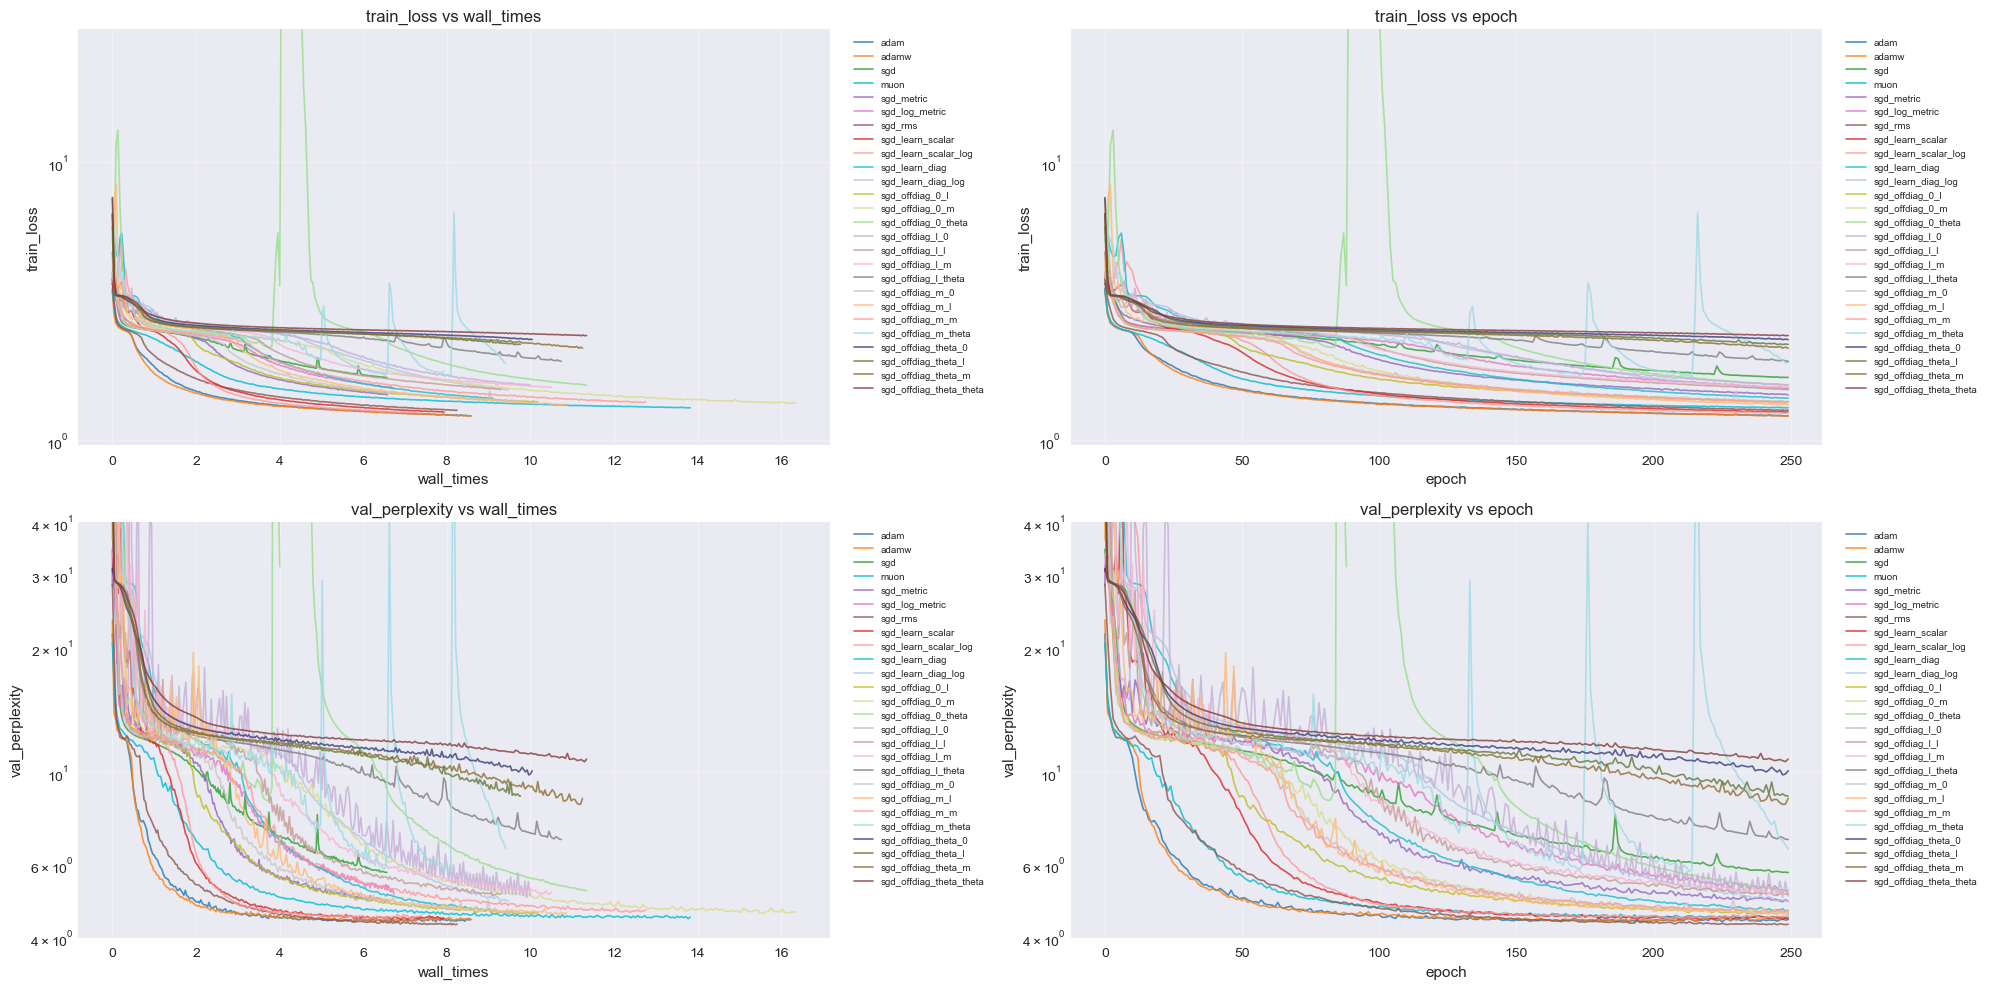

In [7]:
fig = plot_training_curves(
    optimizer_data,
    x_keys=["wall_times", "epoch"],
    y_keys=["train_loss", "val_perplexity"],
    colors=colors,
    ylim={
        "train_loss": (None, 30),
        "val_perplexity": (4, 40),
    },
)
plt.show()


# Speedrun Analysis


Speedrun Results: Time (seconds) to reach target validation perplexity
Optimizer                12.0      10.0      8.0       6.0       5.0       4.6       4.5       4.4       4.0       3.5       
-----------------------------------------------------------------------------------------------------------------------------
adam                     0.3       0.5       0.7       1.1       1.8       2.7       3.6       5.1       --        --        
adamw                    0.3       0.5       0.6       1.0       1.6       2.7       3.8       5.5       --        --        
sgd                      0.8       2.1       3.0       5.8       --        --        --        --        --        --        
muon                     0.4       1.1       1.6       2.5       4.0       7.2       9.9       --        --        --        
sgd_metric               1.1       2.2       2.5       3.4       5.9       --        --        --        --        --        
sgd_log_metric           0.9       2.6       3.

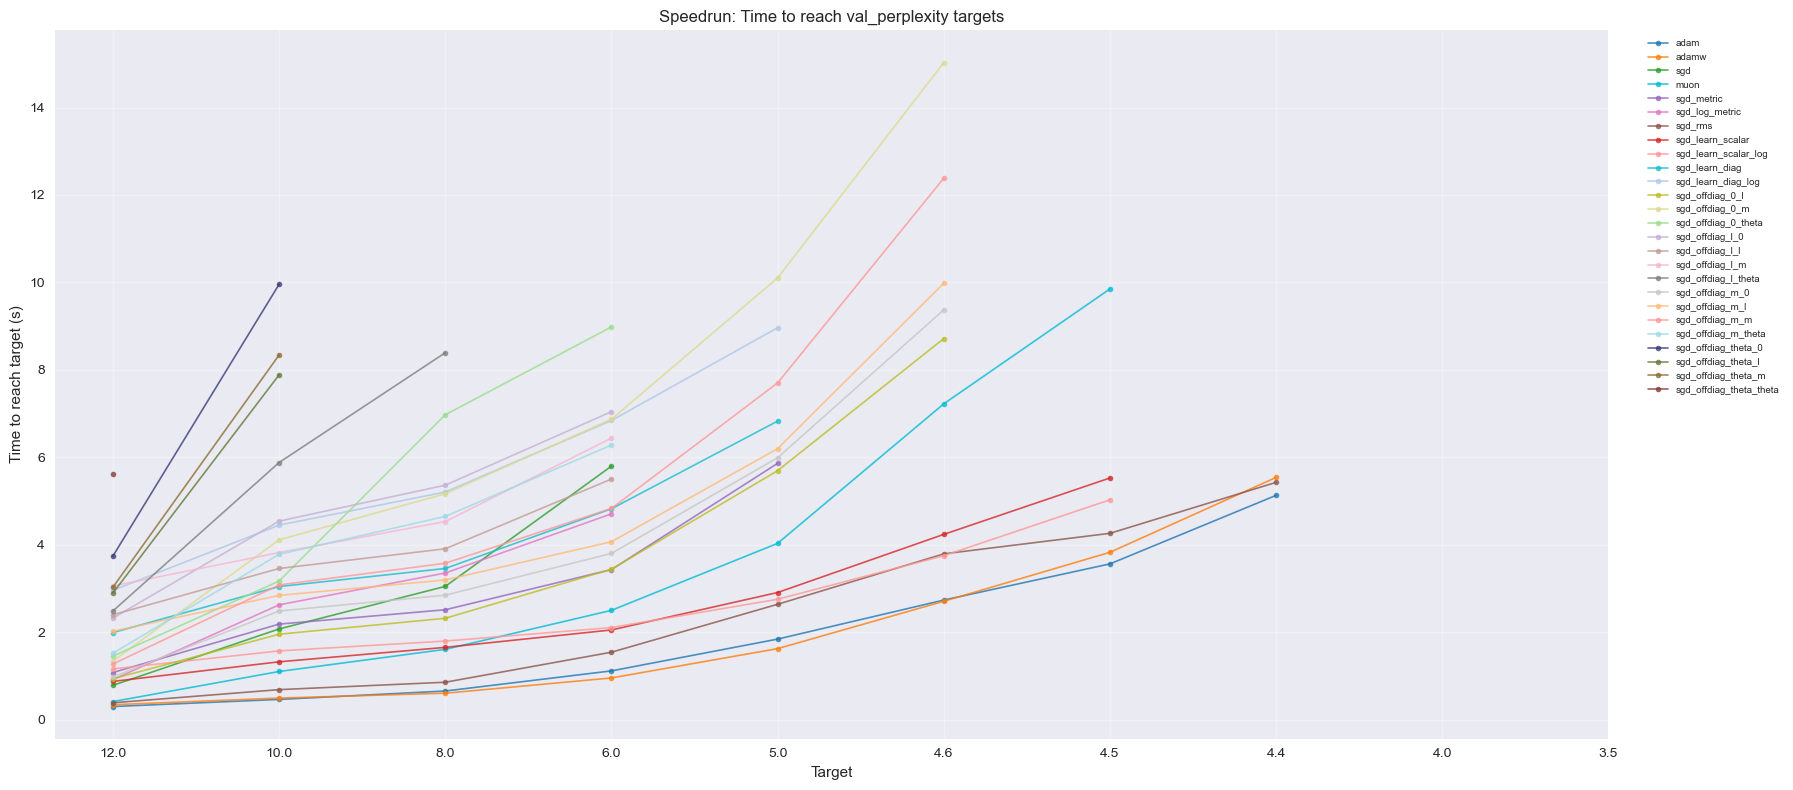

In [8]:
print("Speedrun Results: Time (seconds) to reach target validation perplexity")
print("=" * 80)
print_speedrun_table(optimizer_data, SPEEDRUN_TARGETS, SPEEDRUN_METRIC, SPEEDRUN_DIRECTION)

fig = plot_speedrun_results(
    optimizer_data, SPEEDRUN_TARGETS,
    metric_key=SPEEDRUN_METRIC,
    direction=SPEEDRUN_DIRECTION,
    colors=colors,
)
plt.show()


# Best Hyperparameters


In [9]:
print_best_hyperparameters(best_runs)

filename = f'best_hyperparameters_Shakespeare_itr_{ITERATION}.csv'
df = save_best_hyperparameters(best_runs, filename)
df

Hyperparameters for Best Runs

ADAM:
  Run name: run_77
  Config:
    learning_rate: 0.003299587515665484
    beta1: 0.5711348457800955
    beta2: 0.8984542869943909
    eps: 1e-08
    batch_size: 256
    n_epochs: 250
  sweep_metric: 4.364747
  final_min_val_perplexity: 4.364747
----------------------------------------

ADAMW:
  Run name: run_158
  Config:
    learning_rate: 0.0038171752108588385
    beta1: 0.5267923504126625
    beta2: 0.8214236850668213
    eps: 1e-08
    weight_decay: 0.000172608363137768
    batch_size: 256
    n_epochs: 250
  sweep_metric: 4.384629
  final_min_val_perplexity: 4.384629
----------------------------------------

SGD:
  Run name: run_98
  Config:
    learning_rate: 0.12069513145865542
    momentum: 0.8881391573530513
    batch_size: 256
    n_epochs: 250
  sweep_metric: 5.736539
  final_min_val_perplexity: 5.736539
----------------------------------------

MUON:
  Run name: run_59
  Config:
    learning_rate: 0.004525877765425729
    adam_b1: 0.76229

,optimizer,run_name,learning_rate,beta1,beta2,eps,batch_size,n_epochs,total_training_time_sec,total_training_time_min,...,adam_b2,beta,xi,beta_rms,metric_lr,metric_reg,metric_clip,gamma,base_mode,use_momentum_for_update
0,adam,run_77,0.003300,0.571135,0.898454,1.000000e-08,256,250,118.959508,1.982658,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adamw,run_158,0.003817,0.526792,0.821424,1.000000e-08,256,250,118.631597,1.977193,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sgd,run_98,0.120695,NaN,NaN,NaN,256,250,116.905860,1.948431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,muon,run_59,0.004526,NaN,NaN,1.000000e-08,256,250,127.427800,2.123797,...,0.843143,0.810822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,sgd_metric,run_115,4.432455,NaN,NaN,NaN,256,250,117.815622,1.963594,...,NaN,0.741137,5.085697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,sgd_log_metric,run_115,4.432455,NaN,NaN,NaN,256,250,118.570273,1.976171,...,NaN,0.741137,5.085697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sgd_rms,run_175,1.327125,NaN,NaN,1.000000e-08,256,250,119.513460,1.991891,...,NaN,0.891404,5.705199,0.999487,NaN,NaN,NaN,NaN,NaN,NaN
7,sgd_learn_scalar,run_30,3.830100,NaN,NaN,NaN,256,250,119.759416,1.995990,...,NaN,0.681378,4.565176,NaN,0.438120,0.000052,4.866619,NaN,NaN,NaN
8,sgd_learn_scalar_log,run_30,3.830100,NaN,NaN,NaN,256,250,120.432738,2.007212,...,NaN,0.681378,4.565176,NaN,0.438120,0.000052,4.866619,NaN,NaN,NaN
9,sgd_learn_diag,run_61,4.496560,NaN,NaN,NaN,256,250,120.767869,2.012798,...,NaN,0.803865,0.066470,NaN,0.000087,0.000072,2.413409,NaN,NaN,NaN
